# Bước 4: Khám Phá Đặc Tính Dữ Liệu (Explore Data Characteristics)

Khám phá đặc tính dữ liệu giúp hiểu cấu trúc và định hướng phân tích.

**Mục tiêu:**
- Chuyển đổi kiểu dữ liệu phù hợp
- Phân tích phân bố các biến
- Thống kê mô tả chi tiết

## 4.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ Thư viện đã được import thành công!")

✅ Thư viện đã được import thành công!


## 4.2 Tải dữ liệu

In [2]:
# Tải dữ liệu đã xử lý từ Bước 3 (nếu có)
try:
    df = pd.read_pickle('outputs/df_step3.pkl')
    print("✅ Đã tải dữ liệu từ Bước 3")
except:
    DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
    df = pd.read_csv(DATA_PATH, nrows=50000, low_memory=False)
    print("📂 Đã tải dữ liệu gốc")

print(f"📊 Kích thước: {df.shape[0]:,} hàng × {df.shape[1]} cột")

✅ Đã tải dữ liệu từ Bước 3
📊 Kích thước: 50,000 hàng × 111 cột


## 4.3 Chuyển đổi kiểu dữ liệu

In [3]:
print("=" * 70)
print("🔄 CHUYỂN ĐỔI KIỂU DỮ LIỆU")
print("=" * 70)

# Chuyển đổi cột ngày tháng
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']
for col in date_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')
        print(f"✅ {col}: object → datetime")

# Chuyển đổi cột Senior Management nếu có
if 'Senior Management' in df.columns:
    df['Senior Management'] = df['Senior Management'].astype(bool)
    print("✅ Senior Management: object → bool")

🔄 CHUYỂN ĐỔI KIỂU DỮ LIỆU
✅ issue_d: object → datetime
✅ earliest_cr_line: object → datetime
✅ last_pymnt_d: object → datetime
✅ last_credit_pull_d: object → datetime


In [4]:
# Kiểm tra kết quả
print("\nKiểu dữ liệu sau chuyển đổi:")
print(df.dtypes.value_counts())


Kiểu dữ liệu sau chuyển đổi:
float64           87
object            19
datetime64[ns]     4
int64              1
Name: count, dtype: int64


## 4.4 Thống kê mô tả biến số

In [5]:
print("=" * 70)
print("📊 THỐNG KÊ MÔ TẢ - BIẾN SỐ")
print("=" * 70)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Thống kê mở rộng
num_stats = df[num_cols].describe().T
num_stats['median'] = df[num_cols].median()
num_stats['skew'] = df[num_cols].skew()
num_stats['kurtosis'] = df[num_cols].kurtosis()

print(num_stats.round(2))

📊 THỐNG KÊ MÔ TẢ - BIẾN SỐ


                              count         mean         std       min  \
id                          50000.0  66709630.20  1942339.11  67025.00   
loan_amnt                   50000.0     15019.36     8676.10   1000.00   
funded_amnt                 50000.0     15019.36     8676.10   1000.00   
funded_amnt_inv             50000.0     15011.82     8671.13    950.00   
int_rate                    50000.0        12.23        4.19      5.32   
...                             ...          ...         ...       ...   
tax_liens                   50000.0         0.07        0.46      0.00   
tot_hi_cred_lim             50000.0    177413.67   177213.07   2500.00   
total_bal_ex_mort           50000.0     53379.38    48878.27      0.00   
total_bc_limit              50000.0     22659.87    22499.38      0.00   
total_il_high_credit_limit  50000.0     45272.65    44713.72      0.00   

                                    25%          50%          75%  \
id                          65946836.25  6

## 4.5 Phân tích phân bố biến số chính

📈 PHÂN BỐ CÁC BIẾN SỐ CHÍNH (5 biến)


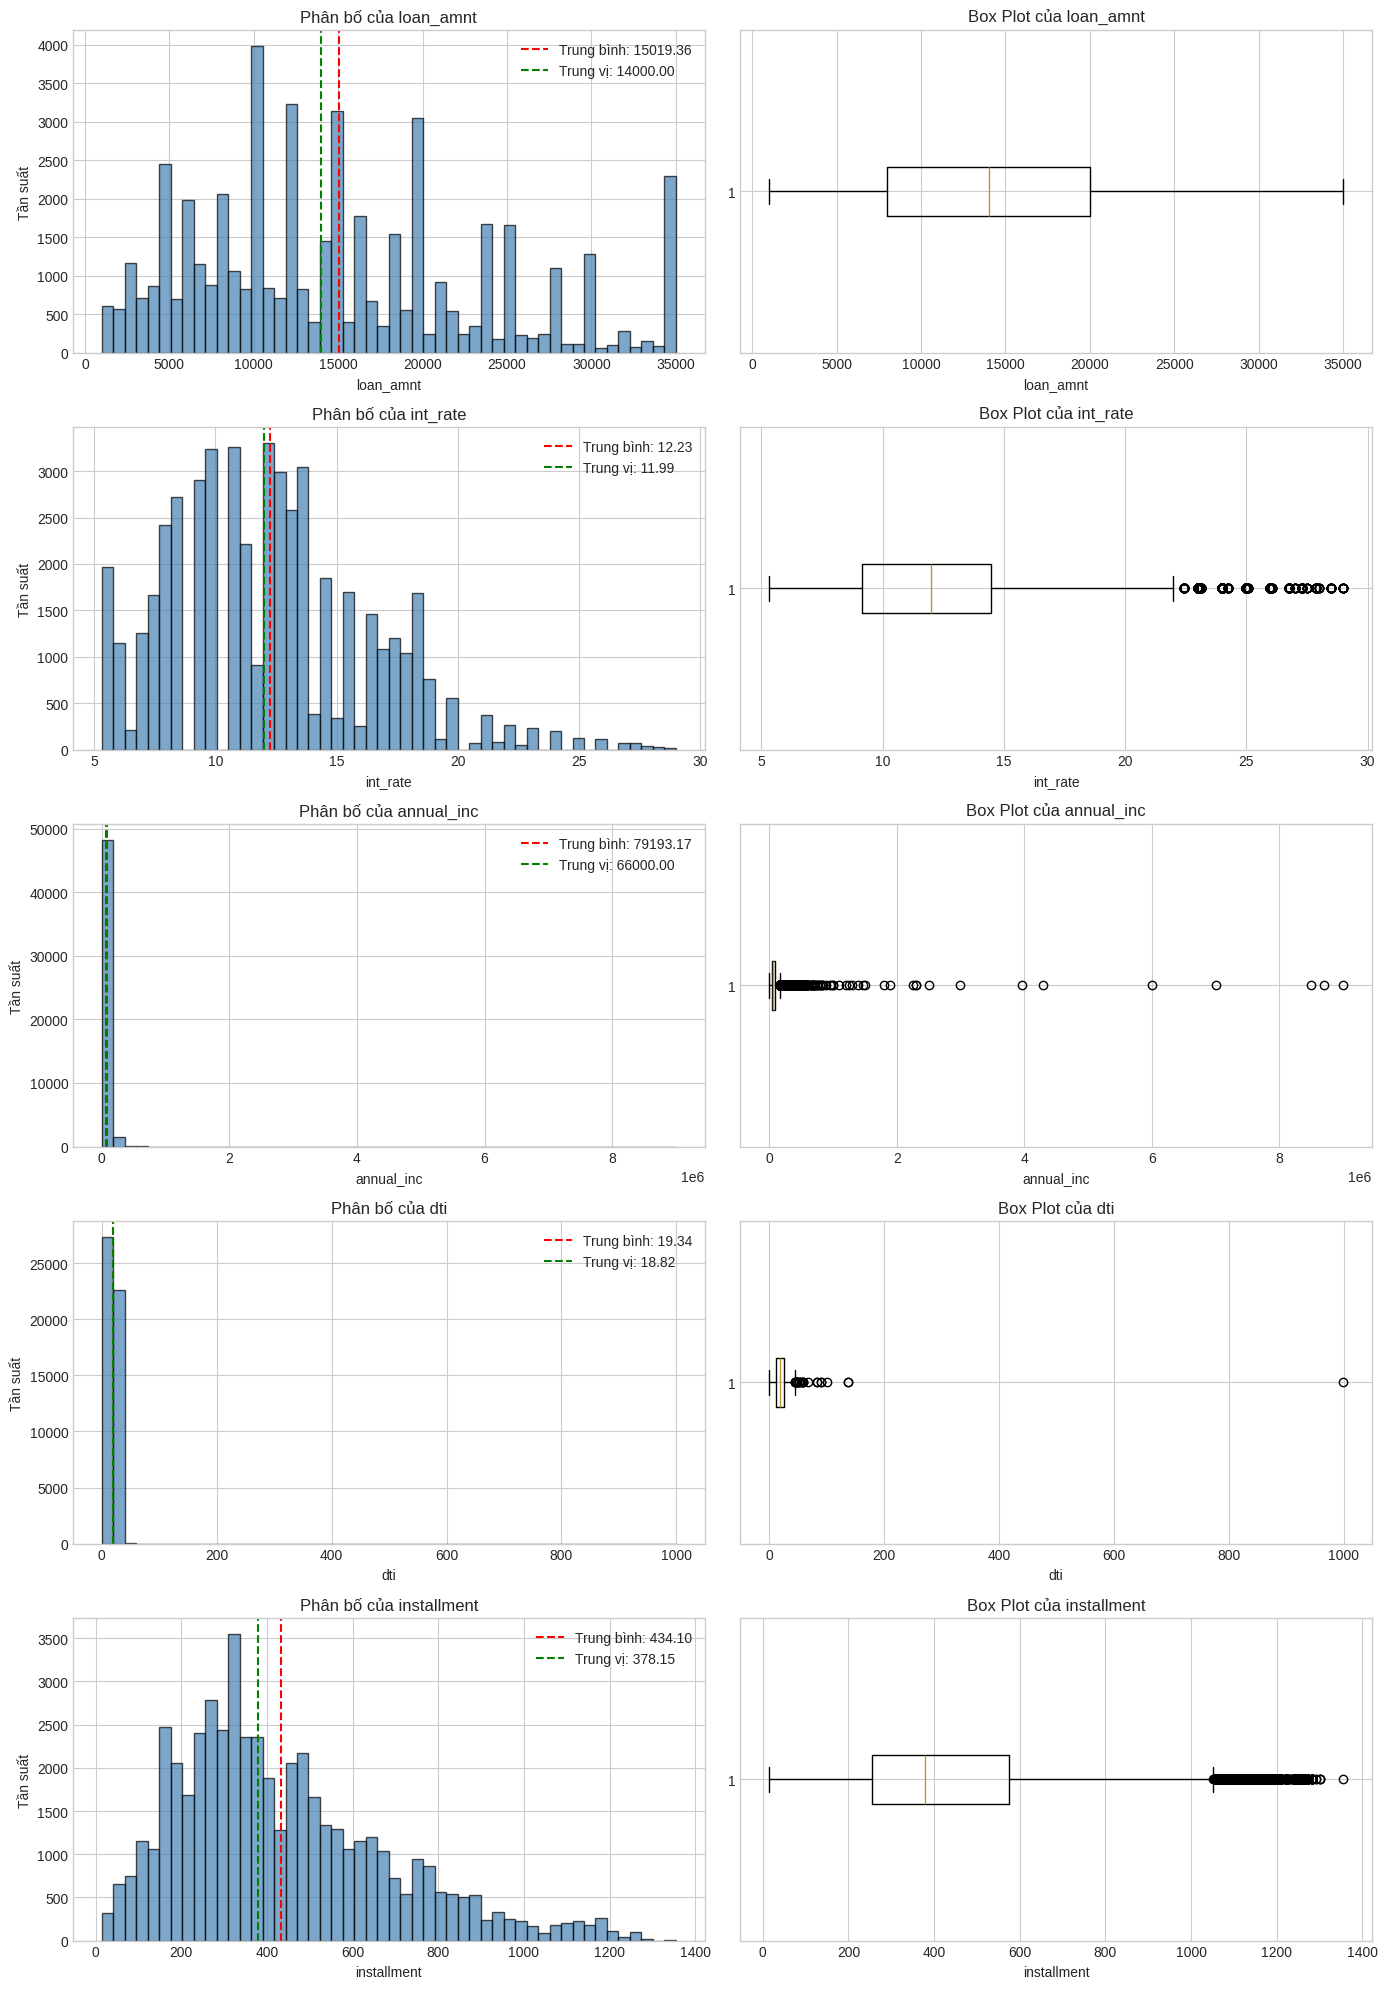

In [6]:
# Chọn các biến quan trọng
key_num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment']
key_num_cols = [col for col in key_num_cols if col in num_cols]

print("=" * 70)
print(f"📈 PHÂN BỐ CÁC BIẾN SỐ CHÍNH ({len(key_num_cols)} biến)")
print("=" * 70)

fig, axes = plt.subplots(len(key_num_cols), 2, figsize=(14, 4*len(key_num_cols)))

for i, col in enumerate(key_num_cols):
    # Histogram
    ax1 = axes[i, 0] if len(key_num_cols) > 1 else axes[0]
    data = df[col].dropna()
    ax1.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(data.mean(), color='red', linestyle='--', label=f'Trung bình: {data.mean():.2f}')
    ax1.axvline(data.median(), color='green', linestyle='--', label=f'Trung vị: {data.median():.2f}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Tần suất')
    ax1.set_title(f'Phân bố của {col}')
    ax1.legend()
    
    # Box plot
    ax2 = axes[i, 1] if len(key_num_cols) > 1 else axes[1]
    ax2.boxplot(data, vert=False)
    ax2.set_xlabel(col)
    ax2.set_title(f'Box Plot của {col}')

plt.tight_layout()
plt.savefig('outputs/04_numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Thống kê mô tả biến phân loại

In [7]:
print("=" * 70)
print("📊 THỐNG KÊ MÔ TẢ - BIẾN PHÂN LOẠI")
print("=" * 70)

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols[:10]:  # Top 10 cột
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    print(f"Số giá trị duy nhất: {len(vc)}")
    if len(vc) <= 10:
        print(vc)
    else:
        print(vc.head(5))
        print(f"... và {len(vc) - 5} giá trị khác")

📊 THỐNG KÊ MÔ TẢ - BIẾN PHÂN LOẠI

--- term ---
Số giá trị duy nhất: 2
term
36 months    34177
60 months    15823
Name: count, dtype: int64

--- grade ---
Số giá trị duy nhất: 7
grade
B    15264
C    14516
A     8641
D     6872
E     3496
F      989
G      222
Name: count, dtype: int64

--- sub_grade ---
Số giá trị duy nhất: 35
sub_grade
C1    3309
B4    3260
B3    3241
B5    3134
C4    3054
Name: count, dtype: int64
... và 30 giá trị khác

--- emp_title ---
Số giá trị duy nhất: 21288
emp_title
Teacher             3989
Manager              832
Owner                560
Registered Nurse     386
Supervisor           377
Name: count, dtype: int64
... và 21283 giá trị khác

--- emp_length ---
Số giá trị duy nhất: 11
emp_length
10+ years    19701
< 1 year      4511
2 years       4414
3 years       4032
1 year        3259
Name: count, dtype: int64
... và 6 giá trị khác

--- home_ownership ---
Số giá trị duy nhất: 4
home_ownership
MORTGAGE    24586
RENT        19660
OWN          5753
ANY      

## 4.7 Phân tích phân bố biến phân loại chính

📊 PHÂN BỐ BIẾN PHÂN LOẠI CHÍNH (5 biến)


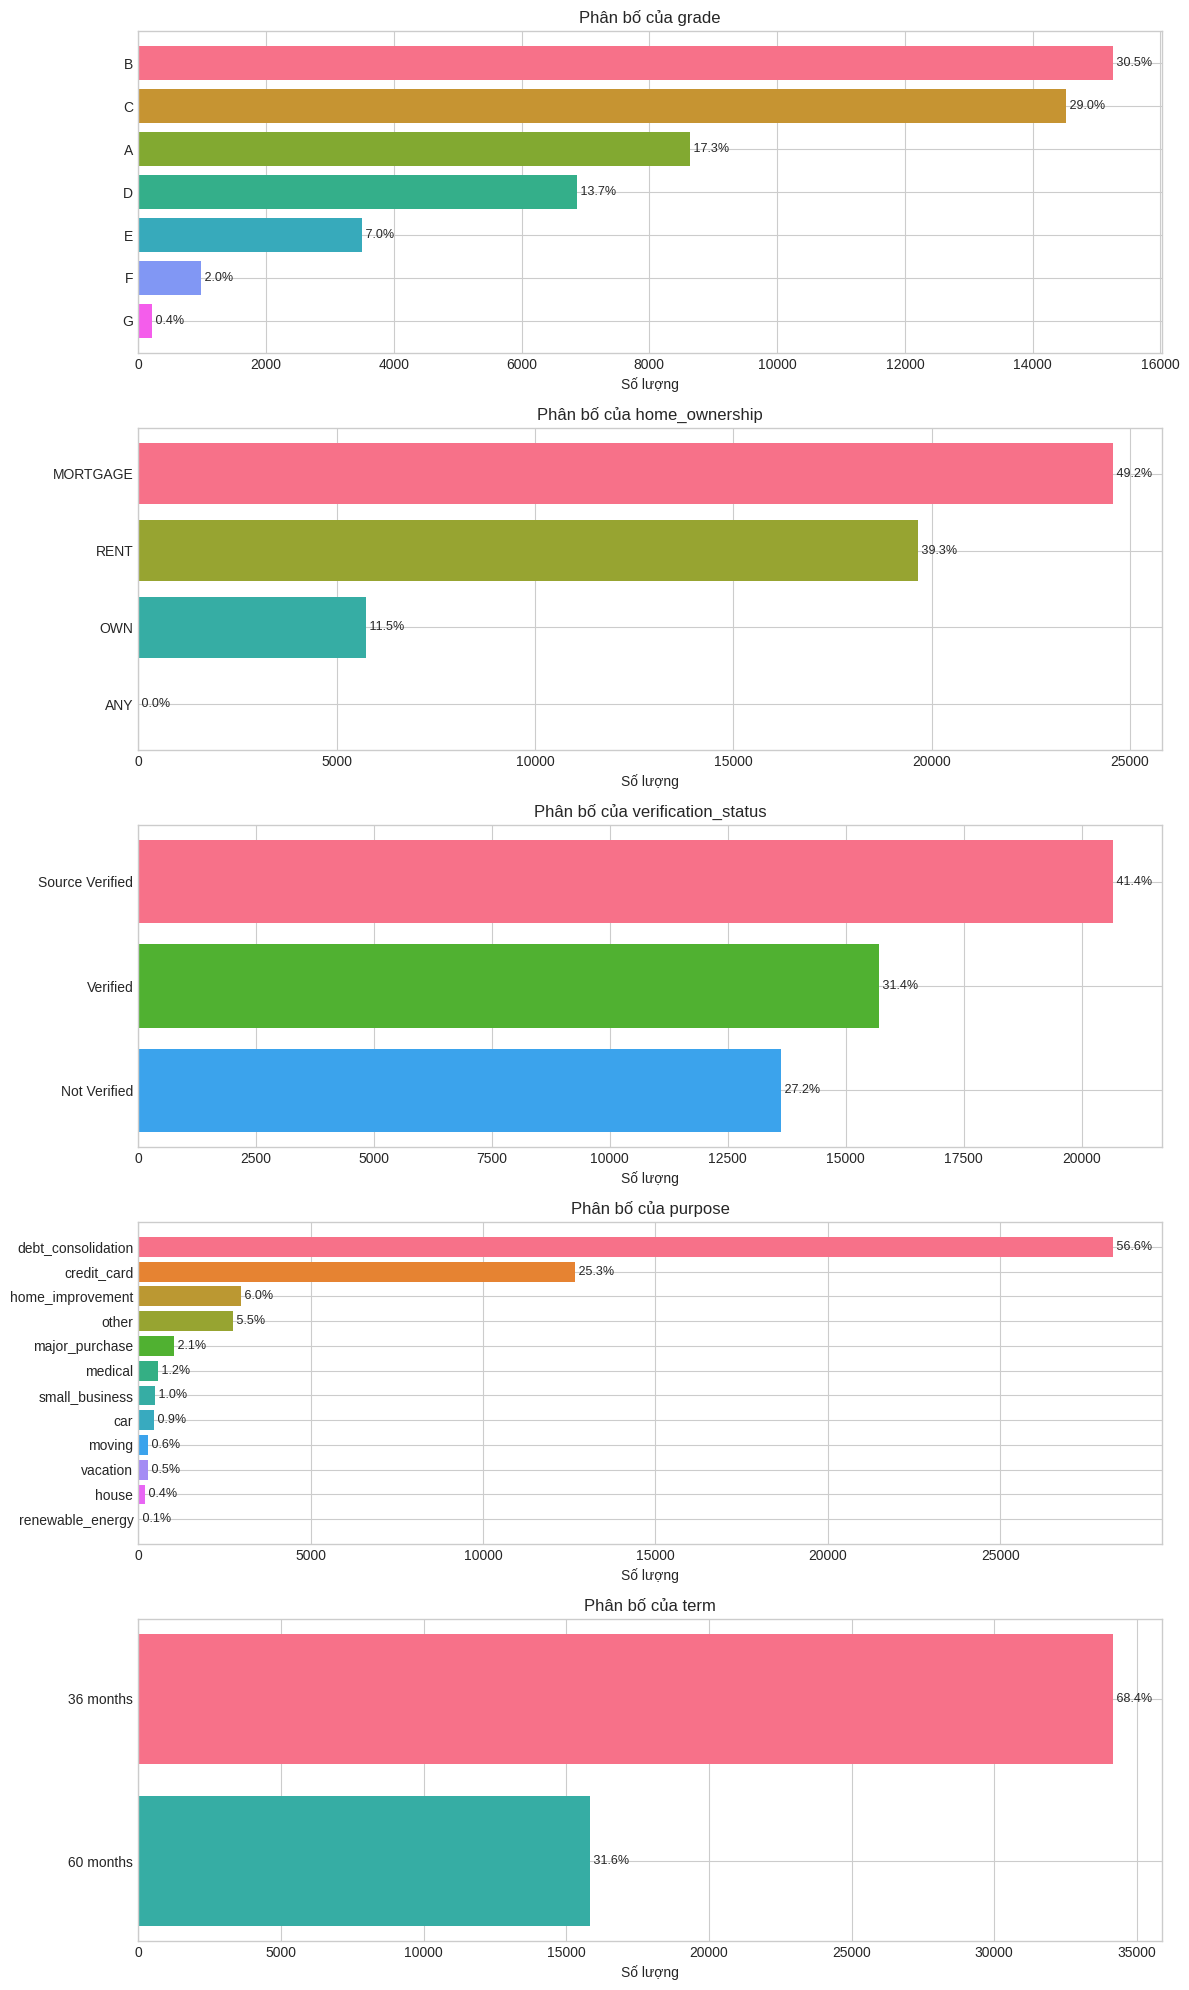

In [8]:
key_cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']
key_cat_cols = [col for col in key_cat_cols if col in df.columns]

print("=" * 70)
print(f"📊 PHÂN BỐ BIẾN PHÂN LOẠI CHÍNH ({len(key_cat_cols)} biến)")
print("=" * 70)

fig, axes = plt.subplots(len(key_cat_cols), 1, figsize=(12, 4*len(key_cat_cols)))

for i, col in enumerate(key_cat_cols):
    ax = axes[i] if len(key_cat_cols) > 1 else axes
    vc = df[col].value_counts()
    
    # Giới hạn hiển thị 15 giá trị
    if len(vc) > 15:
        vc = vc.head(15)
    
    bars = ax.barh(range(len(vc)), vc.values, color=sns.color_palette("husl", len(vc)))
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(vc.index)
    ax.set_xlabel('Số lượng')
    ax.set_title(f'Phân bố của {col}')
    ax.invert_yaxis()
    
    # Thêm % vào từng bar
    for j, (count, _) in enumerate(zip(vc.values, vc.index)):
        pct = count / len(df) * 100
        ax.text(count, j, f' {pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/04_categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.8 Phân tích biến mục tiêu (loan_status)

🎯 PHÂN TÍCH BIẾN MỤC TIÊU: loan_status

Phân bố trạng thái khoản vay:
  Fully Paid: 34,978 (69.96%)
  Charged Off: 9,027 (18.05%)
  Current: 5,610 (11.22%)
  Late (31-120 days): 246 (0.49%)
  In Grace Period: 100 (0.20%)
  Late (16-30 days): 38 (0.08%)
  Default: 1 (0.00%)


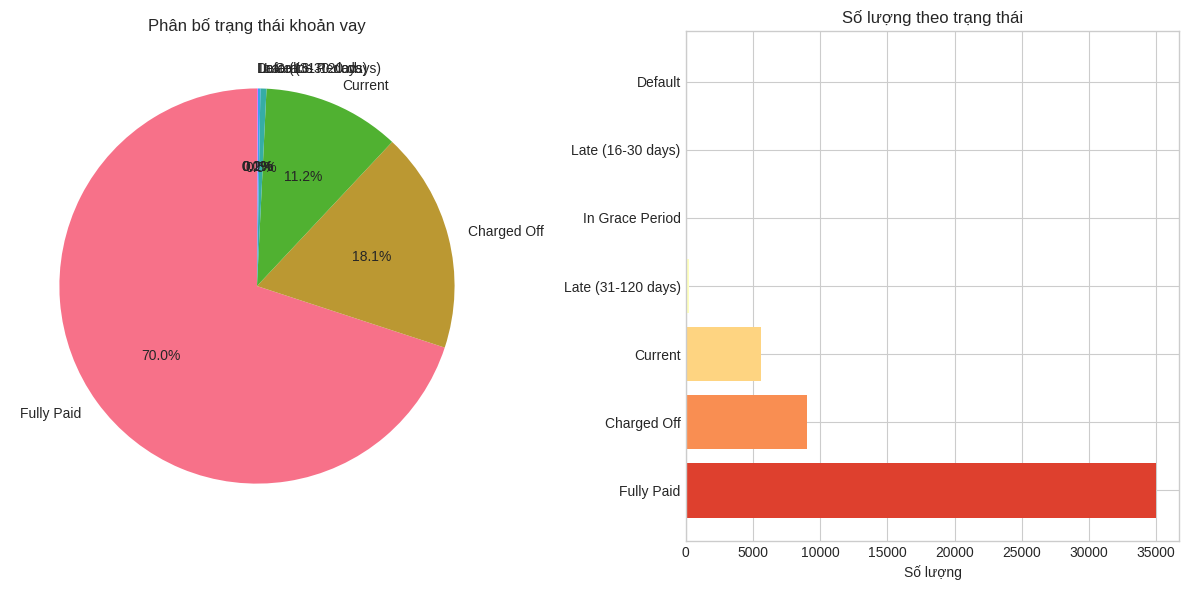

In [9]:
if 'loan_status' in df.columns:
    print("=" * 70)
    print("🎯 PHÂN TÍCH BIẾN MỤC TIÊU: loan_status")
    print("=" * 70)
    
    status_counts = df['loan_status'].value_counts()
    print("\nPhân bố trạng thái khoản vay:")
    for status, count in status_counts.items():
        pct = count / len(df) * 100
        print(f"  {status}: {count:,} ({pct:.2f}%)")
    
    # Visualize
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Phân bố trạng thái khoản vay')
    
    plt.subplot(1, 2, 2)
    colors = sns.color_palette("RdYlGn", len(status_counts))
    plt.barh(status_counts.index, status_counts.values, color=colors)
    plt.xlabel('Số lượng')
    plt.title('Số lượng theo trạng thái')
    
    plt.tight_layout()
    plt.savefig('outputs/04_loan_status.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4.9 Phân tích tương quan

🔗 MA TRẬN TƯƠNG QUAN


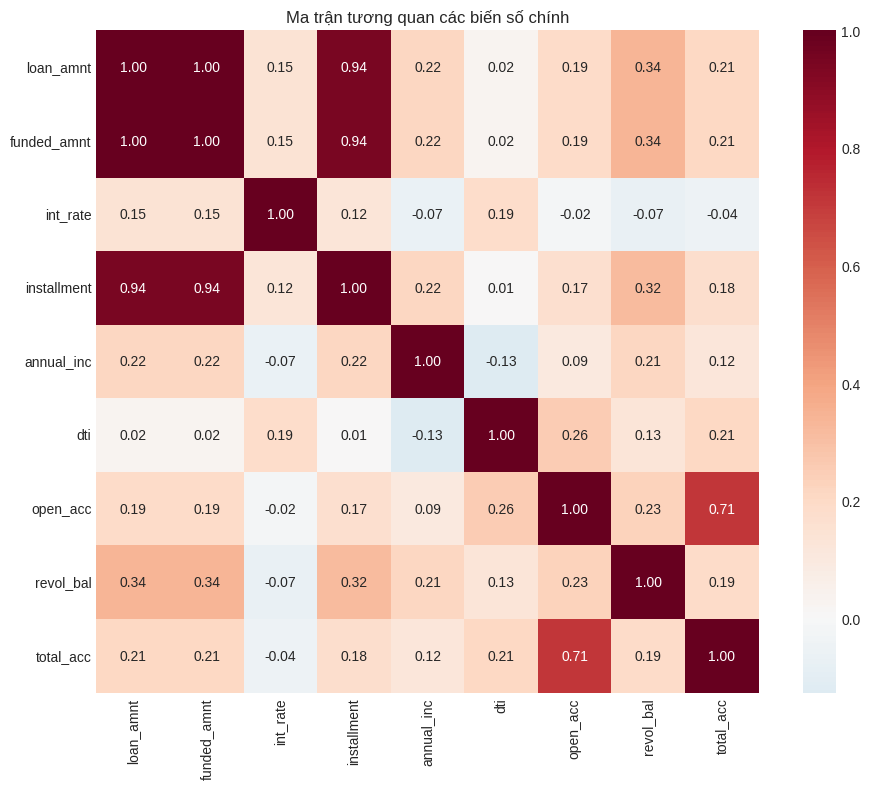

In [10]:
print("=" * 70)
print("🔗 MA TRẬN TƯƠNG QUAN")
print("=" * 70)

# Chọn biến số quan trọng
corr_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 
             'annual_inc', 'dti', 'open_acc', 'revol_bal', 'total_acc']
corr_cols = [col for col in corr_cols if col in num_cols]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Ma trận tương quan các biến số chính')
plt.tight_layout()
plt.savefig('outputs/04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.10 Tổng kết Bước 4

In [11]:
print("=" * 70)
print("📋 TỔNG KẾT BƯỚC 4: KHÁM PHÁ ĐẶC TÍNH DỮ LIỆU")
print("=" * 70)
print(f"""
✅ ĐÃ HOÀN THÀNH:
   • Chuyển đổi kiểu dữ liệu (date columns → datetime)
   • Phân tích thống kê {len(num_cols)} biến số
   • Phân tích phân bố {len(cat_cols)} biến phân loại
   • Phân tích biến mục tiêu (loan_status)
   • Tạo ma trận tương quan

📊 PHÁT HIỆN CHÍNH:
   • Nhiều biến số có phân bố lệch phải (skewed)
   • loan_amnt và funded_amnt có tương quan cao
   • Biến mục tiêu loan_status không cân bằng

📝 BƯỚC TIẾP THEO:
   → Bước 5: Thực hiện biến đổi dữ liệu
""")

# Lưu dataframe để sử dụng ở các bước sau
df.to_pickle('outputs/df_step4.pkl')
print("\n💾 Đã lưu: outputs/df_step4.pkl")

📋 TỔNG KẾT BƯỚC 4: KHÁM PHÁ ĐẶC TÍNH DỮ LIỆU

✅ ĐÃ HOÀN THÀNH:
   • Chuyển đổi kiểu dữ liệu (date columns → datetime)
   • Phân tích thống kê 88 biến số
   • Phân tích phân bố 19 biến phân loại
   • Phân tích biến mục tiêu (loan_status)
   • Tạo ma trận tương quan

📊 PHÁT HIỆN CHÍNH:
   • Nhiều biến số có phân bố lệch phải (skewed)
   • loan_amnt và funded_amnt có tương quan cao
   • Biến mục tiêu loan_status không cân bằng

📝 BƯỚC TIẾP THEO:
   → Bước 5: Thực hiện biến đổi dữ liệu


💾 Đã lưu: outputs/df_step4.pkl
